# SUPERVISED LEARNING-LINEAR REGRESSION
#### FLIGHT PRICE PREDICTION - 'EASEMYTRIP' - INDIA

In [109]:
import re
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

import joblib
import requests


sns.set_theme(style='whitegrid')
pd.set_option("display.max_columns", None)


In [110]:
# Load our data
df_business = pd.read_csv("business.csv")
df_economy = pd.read_csv("economy.csv")

df_business["class"] = "Business"
df_economy["class"] = "Economy"

df = pd.concat([df_business, df_economy], ignore_index=True)

print(f"Business rows: {len(df_business):,}")
print(f"Economy rows: {len(df_economy):,}")
print(f"Combined rows: {len(df):,}")
df.tail()

Business rows: 93,487
Economy rows: 206,774
Combined rows: 300,261


,date,airline,ch_code,num_code,dep_time,from,time_taken,stop,arr_time,to,price,class
300256,31-03-2022,Vistara,UK,832,07:05,Chennai,13h 50m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,20:55,Hyderabad,"7,697",Economy
300257,31-03-2022,Vistara,UK,832,07:05,Chennai,13h 50m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,20:55,Hyderabad,"7,709",Economy
300258,31-03-2022,Vistara,UK,826,12:30,Chennai,20h 35m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,09:05,Hyderabad,"8,640",Economy
300259,31-03-2022,Vistara,UK,822,09:45,Chennai,23h 20m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,09:05,Hyderabad,"8,640",Economy
300260,31-03-2022,Vistara,UK,824,20:30,Chennai,24h 25m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,20:55,Hyderabad,"8,640",Economy


In [111]:
# Looking at the data
df.info()

print("\nMissing values per column:")
print(df.isna().sum())
print(f"\nExact duplicate rows: {df.duplicated().sum()}")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300261 entries, 0 to 300260
Data columns (total 12 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   date        300261 non-null  object
 1   airline     300261 non-null  object
 2   ch_code     300261 non-null  object
 3   num_code    300261 non-null  int64 
 4   dep_time    300261 non-null  object
 5   from        300261 non-null  object
 6   time_taken  300261 non-null  object
 7   stop        300261 non-null  object
 8   arr_time    300261 non-null  object
 9   to          300261 non-null  object
 10  price       300261 non-null  object
 11  class       300261 non-null  object
dtypes: int64(1), object(11)
memory usage: 27.5+ MB

Missing values per column:
date          0
airline       0
ch_code       0
num_code      0
dep_time      0
from          0
time_taken    0
stop          0
arr_time      0
to            0
price         0
class         0
dtype: int64

Exact duplicate rows: 2


In [112]:
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
after = len(df)

print (f"Dropped {before - after} duplicate row(s). Rows remaining: {after:,}")

Dropped 2 duplicate row(s). Rows remaining: 300,259


In [113]:
# Clean the target column
# Take out the commas and convert it to floats

df["price"] = df["price"].astype(str).str.replace(",", "").astype(float)
df["price"].describe()

count    300259.000000
mean      20883.800386
std       22695.962230
min        1105.000000
25%        4783.000000
50%        7425.000000
75%       42521.000000
max      123071.000000
Name: price, dtype: float64

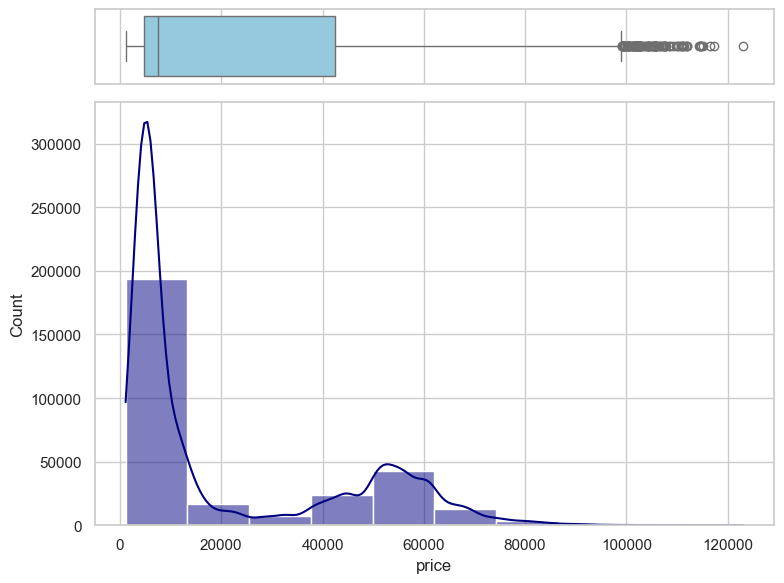

In [114]:
# More exploration of our target feature ("Price")
# Understanding Standard deviation
fig, (ax_box, ax_hist) = plt.subplots(
    2, 1, sharex=True, gridspec_kw={"height_ratios": (0.15, 0.85)}, figsize=(8, 6)
)

sns.boxplot(data=df, x="price", ax=ax_box, color="skyblue")
ax_box.set(xlabel="Price")

sns.histplot(data=df, x="price", ax=ax_hist, bins=10, kde=True, color="navy")

plt.tight_layout()
plt.show()

In [115]:
df.head()

,date,airline,ch_code,num_code,dep_time,from,time_taken,stop,arr_time,to,price,class
0,11-02-2022,Air India,AI,868,18:00,Delhi,02h 00m,non-stop,20:00,Mumbai,25612.0,Business
1,11-02-2022,Air India,AI,624,19:00,Delhi,02h 15m,non-stop,21:15,Mumbai,25612.0,Business
2,11-02-2022,Air India,AI,531,20:00,Delhi,24h 45m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,20:45,Mumbai,42220.0,Business
3,11-02-2022,Air India,AI,839,21:25,Delhi,26h 30m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,23:55,Mumbai,44450.0,Business
4,11-02-2022,Air India,AI,544,17:15,Delhi,06h 40m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,23:55,Mumbai,46690.0,Business


In [116]:
# Turning flight duration (time_taken) into minutes

def parse_duration_to_minutes(time_str: str) -> int:
    """Convert a string like '02h 30m' into total minutes (150)."""
    hours_match = re.search(r"(\d+)h", time_str)
    mins_match = re.search(r"(\d+)m", time_str)
    hours = int(hours_match.group(1)) if hours_match else 0
    mins = int(mins_match.group(1)) if mins_match else 0
    return hours * 60 + mins


df["duration_mins"] = df["time_taken"].apply(parse_duration_to_minutes)
df[["time_taken", "duration_mins"]].head()

,time_taken,duration_mins
0,02h 00m,120
1,02h 15m,135
2,24h 45m,1485
3,26h 30m,1590
4,06h 40m,400


In [117]:
df.head()

,date,airline,ch_code,num_code,dep_time,from,time_taken,stop,arr_time,to,price,class,duration_mins
0,11-02-2022,Air India,AI,868,18:00,Delhi,02h 00m,non-stop,20:00,Mumbai,25612.0,Business,120
1,11-02-2022,Air India,AI,624,19:00,Delhi,02h 15m,non-stop,21:15,Mumbai,25612.0,Business,135
2,11-02-2022,Air India,AI,531,20:00,Delhi,24h 45m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,20:45,Mumbai,42220.0,Business,1485
3,11-02-2022,Air India,AI,839,21:25,Delhi,26h 30m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,23:55,Mumbai,44450.0,Business,1590
4,11-02-2022,Air India,AI,544,17:15,Delhi,06h 40m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,23:55,Mumbai,46690.0,Business,400


In [118]:
# Turning Date into Useful Features

df["flight_date"] = pd.to_datetime(df["date"], format="%d-%m-%Y")

earliest_date = df["flight_date"].min()
df["days_left"] = (df["flight_date"] - earliest_date).dt.days + 1
df["day_of_week"] = df["flight_date"].dt.day_name()

df[["date", "flight_date", "days_left", "day_of_week"]].head()

,date,flight_date,days_left,day_of_week
0,11-02-2022,2022-02-11,1,Friday
1,11-02-2022,2022-02-11,1,Friday
2,11-02-2022,2022-02-11,1,Friday
3,11-02-2022,2022-02-11,1,Friday
4,11-02-2022,2022-02-11,1,Friday


In [119]:
# Categorizing departure and arrival time 

def get_time_block(time_str: str) -> str:
    """Bucket an 'HH:MM' string into a named part of the day"""
    hour = int(time_str.split(":")[0])
    if 4 <= hour < 8:
        return "Early Morning"
    elif 8 <= hour < 12:
        return "Morning"
    elif 12 <= hour < 16:
        return "Afternoon"
    elif 16 <= hour < 20:
        return "Evening"
    else:
        return "Night"


df["dep_time_block"] = df["dep_time"].apply(get_time_block)
df["arr_time_block"] = df["arr_time"].apply(get_time_block)
df[["dep_time", "dep_time_block", "arr_time", "arr_time_block"]].head()

,dep_time,dep_time_block,arr_time,arr_time_block
0,18:00,Evening,20:00,Night
1,19:00,Evening,21:15,Night
2,20:00,Night,20:45,Night
3,21:25,Night,23:55,Night
4,17:15,Evening,23:55,Night


In [120]:
df.head()

,date,airline,ch_code,num_code,dep_time,from,time_taken,stop,arr_time,to,price,class,duration_mins,flight_date,days_left,day_of_week,dep_time_block,arr_time_block
0,11-02-2022,Air India,AI,868,18:00,Delhi,02h 00m,non-stop,20:00,Mumbai,25612.0,Business,120,2022-02-11,1,Friday,Evening,Night
1,11-02-2022,Air India,AI,624,19:00,Delhi,02h 15m,non-stop,21:15,Mumbai,25612.0,Business,135,2022-02-11,1,Friday,Evening,Night
2,11-02-2022,Air India,AI,531,20:00,Delhi,24h 45m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,20:45,Mumbai,42220.0,Business,1485,2022-02-11,1,Friday,Night,Night
3,11-02-2022,Air India,AI,839,21:25,Delhi,26h 30m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,23:55,Mumbai,44450.0,Business,1590,2022-02-11,1,Friday,Night,Night
4,11-02-2022,Air India,AI,544,17:15,Delhi,06h 40m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,23:55,Mumbai,46690.0,Business,400,2022-02-11,1,Friday,Evening,Night


In [121]:
# Clean up the "stop" column
# Lets take a look at the "stop" column
print(df["stop"].unique()[:5])


['non-stop ' '1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t\t\t\t\t\t\t'
 '1-stop\n\t\t\t\t\t\t\t\t\t\t\t\tVia IDR\n\t\t\t\t\t\t\t\t\t\t\t\t'
 '1-stop\n\t\t\t\t\t\t\t\t\t\t\t\tVia IXU\n\t\t\t\t\t\t\t\t\t\t\t\t'
 '1-stop\n\t\t\t\t\t\t\t\t\t\t\t\tVia Chennai\n\t\t\t\t\t\t\t\t\t\t\t\t']


In [122]:
# Cleaning proper
def clean_stop(stop_str: str) -> str:
    """Collapse messy scraped stop text into a clean 3-value category."""
    stop_str = stop_str.strip()
    if stop_str.startswith("non-stop"):
        return "non-stop"
    if stop_str.startswith("2+-stop"):
        return "2+-stop"
    if stop_str.startswith("1-stop"):
        return "1-stop"
    return stop_str

df["stop"] = df["stop"].apply(clean_stop)
df["stop"].value_counts()

stop
1-stop      250927
non-stop     36044
2+-stop      13288
Name: count, dtype: int64

In [123]:
# Looking at our cleaned dataset

feature_preview_cols = [
    "airline", "from", "to", "class", "stop",
    "day_of_week", "dep_time_block", "arr_time_block",
    "duration_mins", "days_left", "price"
]

df[feature_preview_cols].describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
airline,300259,8,Vistara,127859,NaN,NaN,NaN,NaN,NaN,NaN,NaN
from,300259,6,Delhi,61343,NaN,NaN,NaN,NaN,NaN,NaN,NaN
to,300259,6,Mumbai,59107,NaN,NaN,NaN,NaN,NaN,NaN,NaN
class,300259,2,Economy,206772,NaN,NaN,NaN,NaN,NaN,NaN,NaN
stop,300259,3,1-stop,250927,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day_of_week,300259,7,Monday,44072,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dep_time_block,300259,5,Morning,75250,NaN,NaN,NaN,NaN,NaN,NaN,NaN
arr_time_block,300259,5,Night,107585,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duration_mins,300259.0,NaN,NaN,NaN,733.063339,431.573994,50.0,405.0,675.0,970.0,2990.0
days_left,300259.0,NaN,NaN,NaN,26.004529,13.560967,1.0,15.0,26.0,38.0,49.0


### EXPLORATION DATA ANALYSIS

<function matplotlib.pyplot.show(close=None, block=None)>

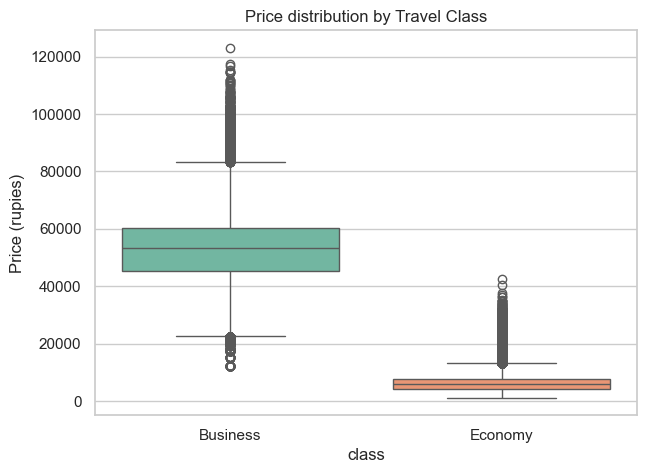

In [124]:
# BI-VARIATE ANALYSIS
# PRICE by TRAVEL CLASS (BUSINESS AND ECONOMY)

plt.figure(figsize=(7,5))
sns.boxplot(data=df, x="class", y="price", hue="class", palette="Set2", legend=False)
plt.title("Price distribution by Travel Class")
plt.ylabel("Price (rupies)")
plt.show

In [125]:
# Checking our outlier 
# (We see they are actually real values... Ridge model would have a bit of problem but we'll deal with this later)

for cls in df["class"].unique():
    prices = df.loc[df["class"] == cls, "price"]
    q1, q3 = prices.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower_fence, upper_fence = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outliers = ((prices < lower_fence) | (prices > upper_fence)).sum()
    pct_outliers = 100 * n_outliers / len(prices)

    print(f"----{cls}-----")
    print(f" IQR fence: {lower_fence:,.0f} to {upper_fence:,.0f}")
    print(f" Flagged as outliers: {n_outliers:,} ({pct_outliers:.1f}% of {cls} rows)")
    print(f" Actual min/max price: {prices.min():,.0f} / {prices.max():,.0f}")
    print()


----Business-----
 IQR fence: 22,368 to 83,212
 Flagged as outliers: 3,650 (3.9% of Business rows)
 Actual min/max price: 12,000 / 123,071

----Economy-----
 IQR fence: -1,186 to 13,106
 Flagged as outliers: 13,750 (6.6% of Economy rows)
 Actual min/max price: 1,105 / 42,349



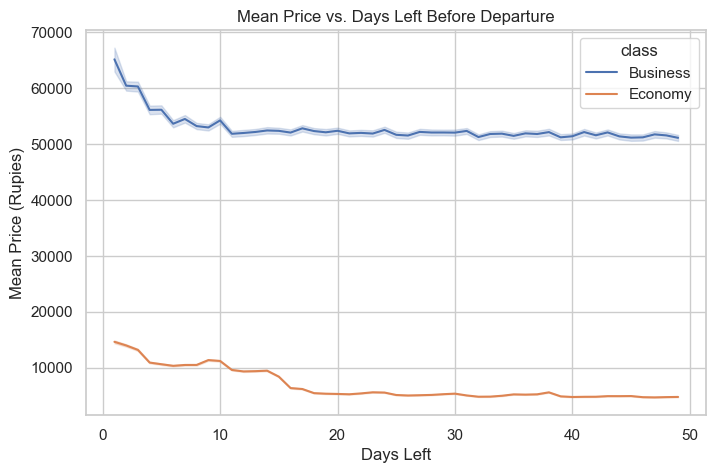

In [126]:
# DOES BOOKING EARLIER SAVE MONEY
# Plotting mean "price" against "days_left", split by class

plt.figure(figsize=(8, 5))
sns.lineplot(data=df, x="days_left", y="price", hue="class", estimator="mean")
plt.title("Mean Price vs. Days Left Before Departure")
plt.xlabel("Days Left")
plt.ylabel("Mean Price (Rupies)")
plt.show()

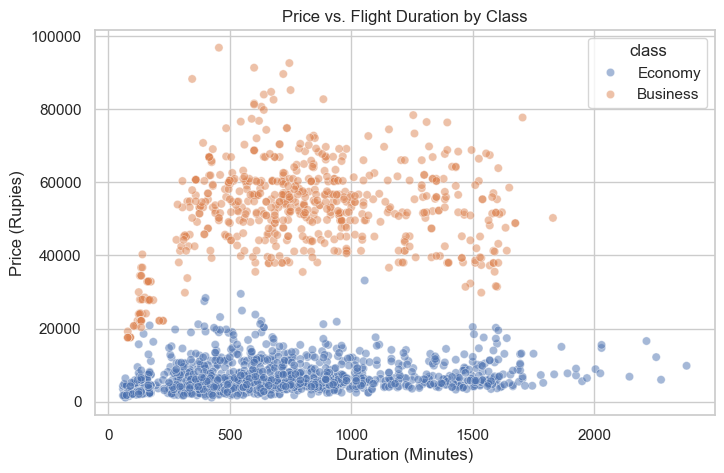

In [127]:
# DOES DURATION AFFECT PRICE
# PRICE VS DURATION

plt.figure(figsize=(8, 5))
sample_df =df.sample(min(2000, len(df)), random_state=42)
sns.scatterplot(data=sample_df, x="duration_mins", y="price", hue="class", alpha=0.5)
plt.title("Price vs. Flight Duration by Class")
plt.xlabel("Duration (Minutes)")
plt.ylabel("Price (Rupies)")
plt.show()

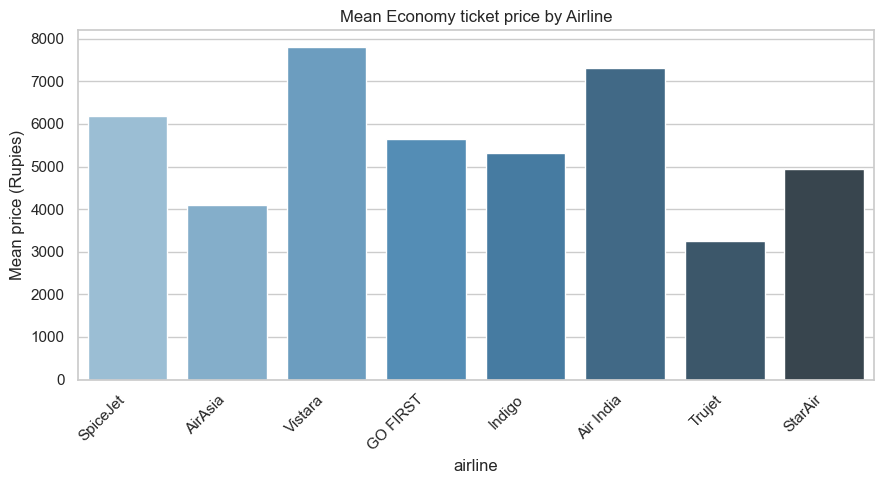

In [128]:
# PRICE BY AIRLINE (ECONOMY)
# Classwork: Do same for "Business Class"

plt.figure(figsize=(9, 5))
economy_df = df[df["class"] == "Economy"]
sns.barplot(data=economy_df, x="airline", y="price", hue="airline",
            errorbar=None, palette="Blues_d", legend=False)
plt.title("Mean Economy ticket price by Airline")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Mean price (Rupies)")
plt.tight_layout()
plt.show()

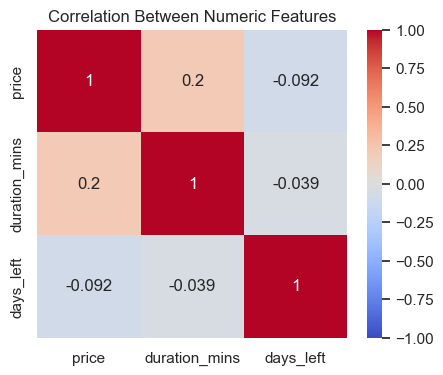

In [129]:
# MULTI-VARIATE ANALYSIS
# HEATMAP OF NUMERIC COLUMNS, HOW THEY RELATE WITH THEMSELVES AND OUR PRICE

numeric_preview = df[["price", "duration_mins", "days_left"]]
plt.figure(figsize=(5, 4))
sns.heatmap(numeric_preview.corr(), annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Between Numeric Features")
plt.show()

### MODELLING

In [130]:
df.head()

,date,airline,ch_code,num_code,dep_time,from,time_taken,stop,arr_time,to,price,class,duration_mins,flight_date,days_left,day_of_week,dep_time_block,arr_time_block
0,11-02-2022,Air India,AI,868,18:00,Delhi,02h 00m,non-stop,20:00,Mumbai,25612.0,Business,120,2022-02-11,1,Friday,Evening,Night
1,11-02-2022,Air India,AI,624,19:00,Delhi,02h 15m,non-stop,21:15,Mumbai,25612.0,Business,135,2022-02-11,1,Friday,Evening,Night
2,11-02-2022,Air India,AI,531,20:00,Delhi,24h 45m,1-stop,20:45,Mumbai,42220.0,Business,1485,2022-02-11,1,Friday,Night,Night
3,11-02-2022,Air India,AI,839,21:25,Delhi,26h 30m,1-stop,23:55,Mumbai,44450.0,Business,1590,2022-02-11,1,Friday,Night,Night
4,11-02-2022,Air India,AI,544,17:15,Delhi,06h 40m,1-stop,23:55,Mumbai,46690.0,Business,400,2022-02-11,1,Friday,Evening,Night


In [131]:
# VERTICAL SPLIT
# FEATURE MATRIX FROM OUR TARGET VARIABLE

categorical_cols = [
    "airline", "from", "to", "class", "stop",
    "day_of_week", "dep_time_block", "arr_time_block"
]

numeric_cols = ["duration_mins", "days_left"]

X = df[categorical_cols + numeric_cols]
y = df["price"]

X.shape, y.shape

((300259, 10), (300259,))

In [132]:
# HORIZONTAL SPLIT
# TRAIN_TEST SPLIT (80/20 SPLIT)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training rows: {len(X_train):,}")
print(f"Test rows: {len(X_test):,}")

Training rows: 240,207
Test rows: 60,052


In [133]:
# BUILDING PREPROCESSING PIPELINE
# ColumnTransformer - this allows us to apply different preprocessing to different columns

preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric_cols),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore",
                          sparse_output=False), categorical_cols)
])
preprocessor

ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['duration_mins', 'days_left']),
                                ('cat',
                                 OneHotEncoder(drop='first',
                                               handle_unknown='ignore',
                                               sparse_output=False),
                                 ['airline', 'from', 'to', 'class', 'stop',
                                  'day_of_week', 'dep_time_block',
                                  'arr_time_block'])])

In [134]:
# MODEL 1 - BASELINE MODEL
# RIDGE REGRESSION

ridge_pipeline = Pipeline([
    ("prep", preprocessor),
    ("reg", Ridge(alpha=1.0))
])
ridge_pipeline

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['duration_mins',
                                                   'days_left']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['airline', 'from', 'to',
                                                   'class', 'stop',
                                                   'day_of_week',
                                                   'dep_time_block',
                                                   'arr_time_block'])])),
                ('reg', Ridge())])

In [135]:
ridge_pipeline.fit(X_train, y_train)
ridge_preds = ridge_pipeline.predict(X_test)

ridge_mae = mean_absolute_error(y_test, ridge_preds)
ridge_r2 = r2_score(y_test, ridge_preds)
print (f"Ridge Baseline -> {ridge_mae:,.2f}rupies | r2: {ridge_r2:.4f}")

Ridge Baseline -> 4,595.68rupies | r2: 0.9097


In [136]:
# MODEL 2 - RANDOM FOREST
rf_pipeline = Pipeline([
    ("prep", preprocessor),
    ("reg", RandomForestRegressor(n_estimators=50, max_depth=10,
                                  random_state=42, n_jobs=-1))
])

rf_pipeline.fit(X_train, y_train)
rf_preds = rf_pipeline.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_preds)
rf_r2 = r2_score(y_test, rf_preds)
print(f"Random Forest -> MAE: {rf_mae:,.2f}rupies | r2: {rf_r2:.2f}")

Random Forest -> MAE: 2,442.80rupies | r2: 0.96


In [137]:
# MODEL 3 - GRADIENT BOOSTING
# HISTGRADIENTBOOSTINGREGRESSOR

gb_pipeline = Pipeline([
    ("prep", preprocessor),
    ("reg", HistGradientBoostingRegressor(max_iter=100, max_depth=8, random_state=42))
])

gb_pipeline.fit(X_train, y_train)
gb_preds = gb_pipeline.predict(X_test)

gb_mae = mean_absolute_error(y_test, gb_preds)
gb_r2 = r2_score(y_test, gb_preds)
print(f"Gradient Boosting -> MAE: {gb_mae:,.2f} | r2: {gb_r2:.4f}")

Gradient Boosting -> MAE: 2,378.56 | r2: 0.9683


### HYPERPARAMETER TUNING

In [138]:
param_grid = {
    "reg__max_iter": [100, 200],
    "reg__max_depth": [10, 15],
    "reg__learning_rate": [0.05, 0.1],
    "reg__min_samples_leaf": [20, 30],
}

search = RandomizedSearchCV(
    gb_pipeline,
    param_distributions=param_grid,
    n_iter=4,
    cv=3,
    scoring="r2",
    random_state=42,
    n_jobs=-1,
)

search

RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('prep',
                                              ColumnTransformer(transformers=[('num',
                                                                               StandardScaler(),
                                                                               ['duration_mins',
                                                                                'days_left']),
                                                                              ('cat',
                                                                               OneHotEncoder(drop='first',
                                                                                             handle_unknown='ignore',
                                                                                             sparse_output=False),
                                                                               ['airline',
                                                                                'from',
                                                                                'to',
                                                                                'class',
                                                                                'stop',
                                                                                'day_of_week',
                                                                                'dep_time_block',
                                                                                'arr_time_block'])])),
                                             ('reg',
                                              HistGradientBoostingRegressor(max_depth=8,
                                                                            random_state=42))]),
                   n_iter=4, n_jobs=-1,
                   param_distributions={'reg__learning_rate': [0.05, 0.1],
                                        'reg__max_depth': [10, 15],
                                        'reg__max_iter': [100, 200],
                                        'reg__min_samples_leaf': [20, 30]},
                   random_state=42, scoring='r2')

In [139]:
search.fit(X_train, y_train)

best_model = search.best_estimator_
best_preds = best_model.predict(X_test)

best_mae = mean_absolute_error(y_test, best_preds)
best_r2 = r2_score(y_test, best_preds)
print(f"Best params: {search.best_params_}")
print(f"Tuned Model -> MAE: {best_mae:,.2f} | r2: {best_r2:.4f}")

Best params: {'reg__min_samples_leaf': 20, 'reg__max_iter': 200, 'reg__max_depth': 15, 'reg__learning_rate': 0.1}
Tuned Model -> MAE: 2,165.85 | r2: 0.9739


#### COMPARING ALL OUR MODELS

In [140]:
results = pd.DataFrame({
    "Model": ["Ridge", "Random Forest", "Gradient Boosting", "Tuned Gradient Boosting"],
    "MAE": [ridge_mae, rf_mae, gb_mae, best_mae],
    "R2": [ridge_r2, rf_r2, gb_r2, best_r2],
})

display(results)

,Model,MAE,R2
0,Ridge,4595.677453,0.909675
1,Random Forest,2442.800905,0.962750
2,Gradient Boosting,2378.564356,0.968313
3,Tuned Gradient Boosting,2165.852611,0.973920


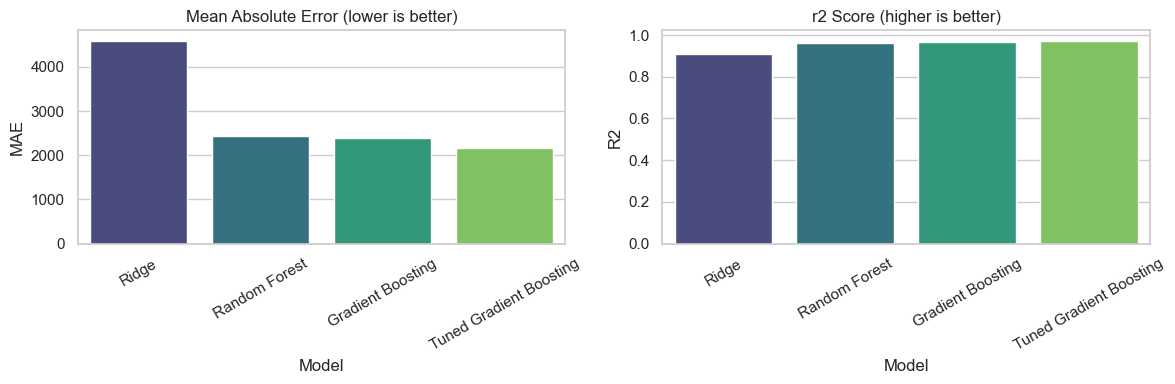

In [141]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(data=results, x="Model", y="MAE", hue="Model", ax=axes[0],
            palette="viridis", legend=False)
axes[0].set_title("Mean Absolute Error (lower is better)")
axes[0].tick_params(axis="x", rotation=30)

sns.barplot(data=results, x="Model", y="R2", hue="Model", ax=axes[1],
            palette="viridis", legend=False)
axes[1].set_title("r2 Score (higher is better)")
axes[1].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

#### DIAGNOSTICS

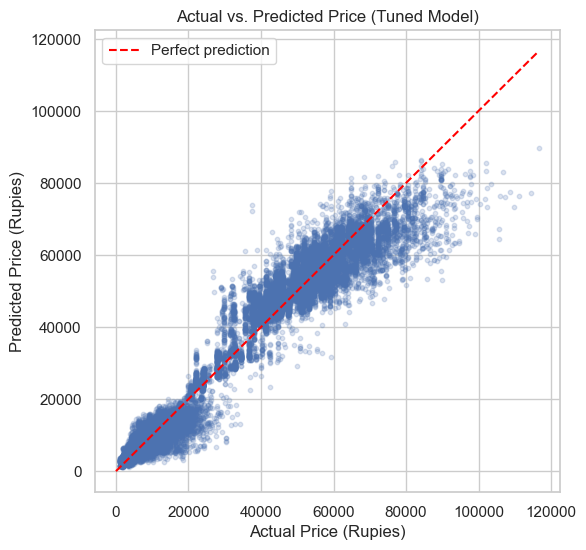

In [142]:
# ACTUAL VS. PREDICTED PRICE

plt.figure(figsize=(6, 6))
plt.scatter(y_test, best_preds, alpha=0.2, s=10)
lims = [0, max(y_test.max(), best_preds.max())]
plt.plot(lims, lims, color="red", linestyle="--", label="Perfect prediction")
plt.xlabel("Actual Price (Rupies)")
plt.ylabel("Predicted Price (Rupies)")
plt.title("Actual vs. Predicted Price (Tuned Model)")
plt.legend()
plt.show()

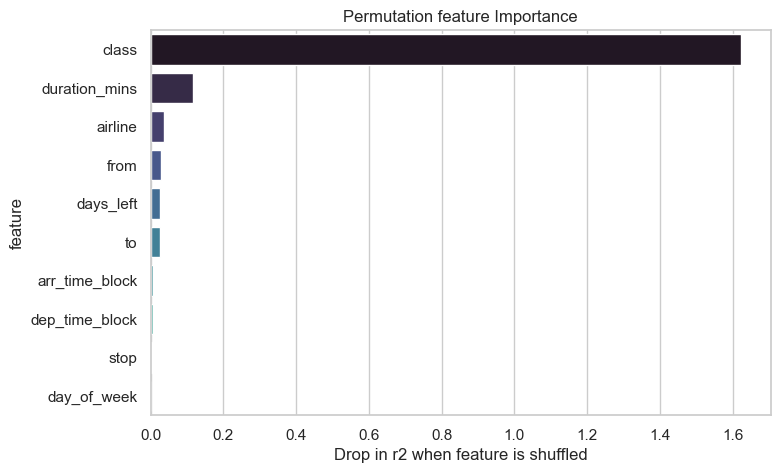

In [143]:
# PERMUTATION IMPORTANCE
importance_sample = X_test.sample(min(3000, len(X_test)), random_state=42)
importance_target = y_test.loc[importance_sample.index]

perm_result = permutation_importance(
    best_model, importance_sample, importance_target,
    n_repeats=5, random_state=42, n_jobs=-1,
)

importance_df = pd.DataFrame({
    "feature": importance_sample.columns,
    "importance": perm_result.importances_mean,
}).sort_values("importance", ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=importance_df, x="importance", y="feature", hue="feature",
            palette="mako", legend=False)
plt.title("Permutation feature Importance")
plt.xlabel("Drop in r2 when feature is shuffled")
plt.show()

#### SAVING OUR PIPELINE

In [144]:
# USING JOBLIB
joblib.dump(best_model, "flight_price_model.pkl")
print("Saved trained pipeline to 'flight_price_model.pkl'")

Saved trained pipeline to 'flight_price_model.pkl'
